In [24]:
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras import Sequential
from tensorflow.keras.layers import LeakyReLU, Conv2D, MaxPooling2D, Dropout, Flatten, Dense
from tensorflow.keras.wrappers.scikit_learn import KerasRegressor


from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import StratifiedKFold, GridSearchCV

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [25]:
main_df = pd.read_csv('energy-train.csv')
holdout = pd.read_csv('energy-holdout.csv')

In [26]:
main_df.columns
# main_df['Minutes'].unique()

Index(['Year', 'Month', 'Day', 'Hours', 'Minutes', 'Time-since-start',
       'Appliances', 'lights', 'T1', 'RH_1', 'T2', 'RH_2', 'T3', 'RH_3', 'T4',
       'RH_4', 'T5', 'RH_5', 'T6', 'RH_6', 'T7', 'RH_7', 'T8', 'RH_8', 'T9',
       'RH_9', 'T_out', 'Press_mm_hg', 'RH_out', 'Windspeed', 'Visibility',
       'Tdewpoint', 'rv1', 'rv2'],
      dtype='object')

In [27]:
def makeItCycle(df, column, period):
  df[column+'sin'] = np.sin(2 * np.pi * df[column]/period)
  df[column+'cos'] = np.cos(2 * np.pi * df[column]/period)
  return df.drop(columns=[column])
def preprocess(X, scaler, resetScaler = False):
  proc = pd.DataFrame(X,copy = True)
  proc = makeItCycle(proc, 'Day', 31)
  proc = makeItCycle(proc, 'Month', 12)
  proc = makeItCycle(proc, 'Hours', 24)
  proc = makeItCycle(proc, 'Minutes', 60)
  if (resetScaler):
    scaler.fit(proc)
  proc = pd.DataFrame(scaler.transform(proc))
  return proc, scaler

In [28]:

X = main_df.drop(columns=["Appliances"])

X, scaler = preprocess(X, scaler=MinMaxScaler(), resetScaler= True)
y = main_df["Appliances"]



def mySplit(X,y,kth):
  X_test = X.iloc[::kth, :]
  y_test = y.iloc[::kth]
  X_train = X[~X.index.isin(X_test.index)]
  y_train = y[~y.index.isin(y_test.index)]
  return X_train, y_train,  X_test, y_test
X_train, y_train, X_val, y_val = mySplit(X, y, 11)



# mySplit(X, y, 9)


#X[~trainIndex]

In [29]:
#run multiple times with different random states
tf.random.set_seed(42)

def create_model(initializer='uniform', activation='selu', optimizer='adam', dropoutRate = 0.1, numExtraLayers = 10):
    model = Sequential()
    if (activation == 'leakyRelu'): activation = LeakyReLU()
    model.add(Dense(128, input_dim=len(X_train.columns), activation=activation))
    model.add(Dropout(dropoutRate))
    model.add(Dense(256, activation=activation))
    model.add(Dropout(dropoutRate))
    # for i in range(0,numExtraLayers):
    #     model.add(Dense(128, activation=activation))
    model.add(Dense(1, activation=activation))
    opt = keras.optimizers.Adam()
    model.compile(loss="msle", optimizer=opt, metrics=['mse'])
    return model

model = create_model(numExtraLayers=3)

In [30]:
param_grid = {
    # 'initializer': ['glorot_uniform'],
    # 'optimizer': ['adam'],
    # 'numExtraLayers': [0],
    # 'dropoutRate' : [0.1],
    # 'batch_size': [24],
    'epochs': [90, 120, 150],
}


In [31]:
early_stop = keras.callbacks.EarlyStopping(monitor='val_loss', patience=5)
#tf.device('/cpu:0')
#tf.device('/device:GPU:0')
history = model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=10000, batch_size=24, callbacks=[early_stop],shuffle=False)
# history = model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=1000, batch_size=24, callbacks=[early_stop],shuffle=False)
# history = model.fit(X_train, y_train, epochs=2000, batch_size=24,shuffle=False)
# history = model.fit(X_train, y_train, epochs=2000, verbose=0, validation_split = .2, batch_size=25,
#                     callbacks=[early_stop])

hist = pd.DataFrame(history.history)

try:
    hist.drop(columns='index', inplace=True)
    hist = pd.concat([hist, pd.DataFrame(history.history)], axis = 0, ignore_index=True)


except:
    hist = pd.DataFrame(history.history)

hist = hist.reset_index()

Epoch 1/10000
527/527 [==============================] - 5s 9ms/step - loss: 0.6651 - mse: 11591.6797 - val_loss: 0.4379 - val_mse: 12601.5391
Epoch 2/10000
527/527 [==============================] - 4s 8ms/step - loss: 0.3768 - mse: 10492.8789 - val_loss: 0.3659 - val_mse: 11696.4355
Epoch 3/10000
527/527 [==============================] - 5s 9ms/step - loss: 0.3232 - mse: 9733.6650 - val_loss: 0.3348 - val_mse: 11069.8066
Epoch 4/10000
527/527 [==============================] - 5s 9ms/step - loss: 0.3119 - mse: 9489.0986 - val_loss: 0.3284 - val_mse: 10974.4561
Epoch 5/10000
527/527 [==============================] - 5s 9ms/step - loss: 0.3071 - mse: 9403.9258 - val_loss: 0.3256 - val_mse: 10844.1924
Epoch 6/10000
527/527 [==============================] - 5s 9ms/step - loss: 0.3065 - mse: 9399.1895 - val_loss: 0.3231 - val_mse: 10844.3174
Epoch 7/10000
527/527 [==============================] - 5s 9ms/step - loss: 0.3030 - mse: 9332.6953 - val_loss: 0.3212 - val_mse: 10766.2246
Epoc

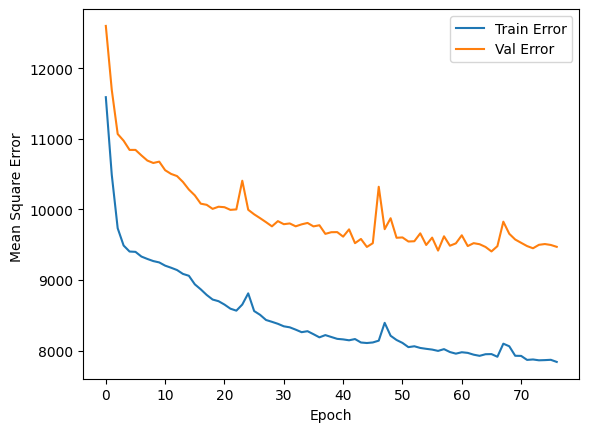

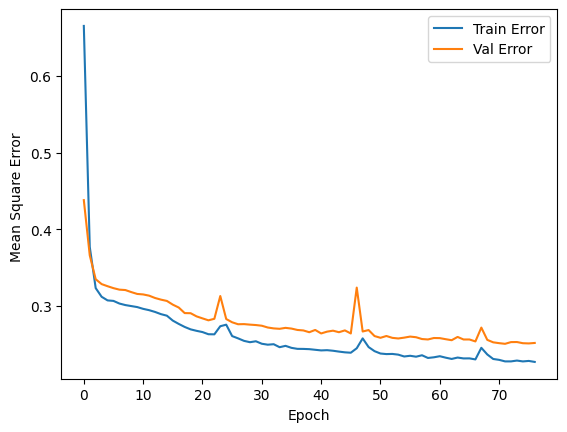

In [32]:
def plot_history(error = 'mse'):
    plt.figure()
    plt.xlabel('Epoch')
    plt.ylabel('Mean Square Error ')
    # plt.plot(hist['index'], hist['loss'], label='Loss')
    plt.plot(hist['index'], hist[error], label='Train Error')
    plt.plot(hist['index'], hist['val_'+ error], label = 'Val Error')
    plt.legend()
    # plt.xlim([300,450])
    # plt.ylim([0,.18])

plot_history()
plot_history(error='loss')

In [33]:
predictions = np.round(model.predict(X_val), 0)
len(predictions)
print("rmse ")
print(mean_squared_error(y_val, predictions, squared=False))
print("r2 ")
r2_score(y_val, predictions)

40/40 [==============================] - 0s 1ms/step
rmse 
97.31689638898689
r2 


0.19462280758394013

In [34]:
def predAndCsv(df, filename): 
    procDf, deleteme = preprocess(pd.DataFrame(data = df, copy=True), scaler=scaler)
    predictions = np.round(model.predict(procDf), 0)
    pd.DataFrame(predictions).clip(lower=0).to_csv(filename, index=False, header= ["Appliances"])
    return predictions
# debug_df = mini_df
# debug_df["predictions"] = predAndCsv(mini_df, "nathan-mini-predictions.csv")
predAndCsv(holdout, "austin3-nn-holdout-predictions.csv")
# predAndCsv(mini_df, "team8-module4-predictions.csv")
# pd.DataFrame(debug_df).to_csv("debug2.csv", index=False)

183/183 [==============================] - 1s 3ms/step


array([[ 42.],
       [ 53.],
       [ 79.],
       ...,
       [ 78.],
       [ 95.],
       [120.]], dtype=float32)